In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

from skimage.metrics import structural_similarity
from sklearn.metrics import mean_squared_error


(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

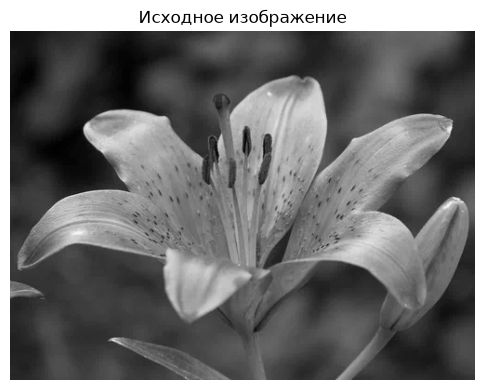

In [2]:
image = cv2.imread("PICT4039.jpg")

image_gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)


plt.figure(figsize=(6,6))
plt.imshow(image_gray, cmap="gray")
plt.title("Исходное изображение")
plt.axis("off")

(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

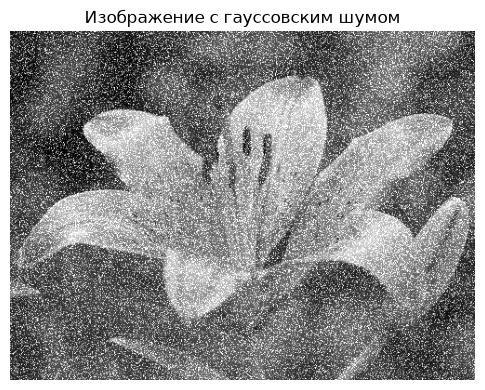

In [3]:
mean = 0
stddev = 100

noise_gauss = np.zeros(
    image_gray.shape,
    np.uint8
)

cv2.randn(
    noise_gauss,
    mean,
    stddev
)


image_noise_gauss = cv2.add(
    image_gray,
    noise_gauss
)


plt.figure(figsize=(6,6))
plt.imshow(
    image_noise_gauss,
    cmap="gray"
)

plt.title(
    "Изображение с гауссовским шумом"
)

plt.axis("off")

Text(0.5, 1.0, 'Median 7')

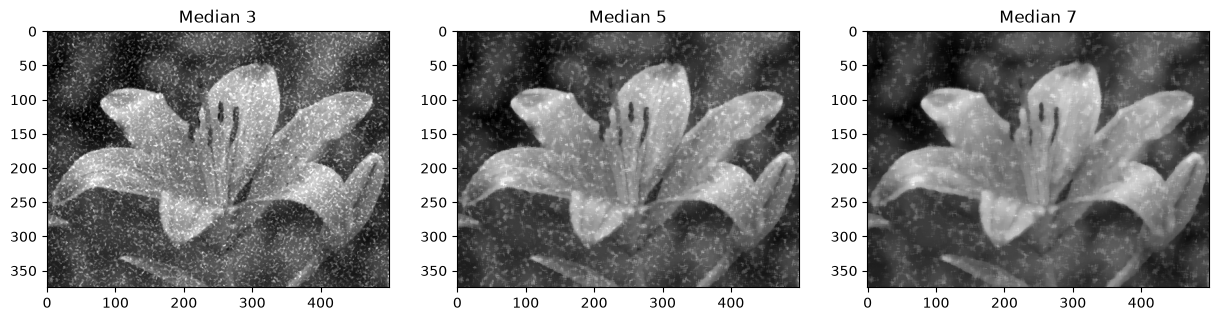

In [5]:
median_3 = cv2.medianBlur(
    image_noise_gauss,
    3
)

median_5 = cv2.medianBlur(
    image_noise_gauss,
    5
)

median_7 = cv2.medianBlur(
    image_noise_gauss,
    7
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(median_3,cmap="gray")
plt.title("Median 3")


plt.subplot(1,3,2)
plt.imshow(median_5,cmap="gray")
plt.title("Median 5")


plt.subplot(1,3,3)
plt.imshow(median_7,cmap="gray")
plt.title("Median 7")

Text(0.5, 1.0, 'Gaussian 7')

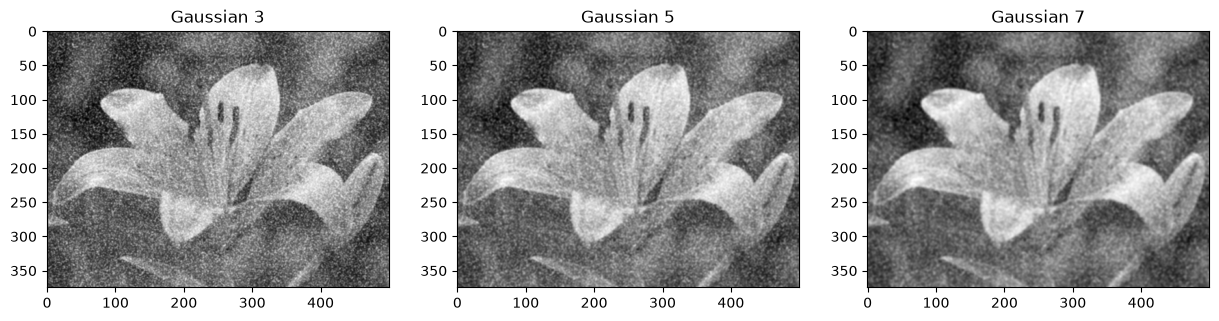

In [6]:
gauss_3 = cv2.GaussianBlur(
    image_noise_gauss,
    (3,3),
    0
)

gauss_5 = cv2.GaussianBlur(
    image_noise_gauss,
    (5,5),
    0
)

gauss_7 = cv2.GaussianBlur(
    image_noise_gauss,
    (7,7),
    0
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(gauss_3,cmap="gray")
plt.title("Gaussian 3")


plt.subplot(1,3,2)
plt.imshow(gauss_5,cmap="gray")
plt.title("Gaussian 5")


plt.subplot(1,3,3)
plt.imshow(gauss_7,cmap="gray")
plt.title("Gaussian 7")

Text(0.5, 1.0, 'Bilateral 3')

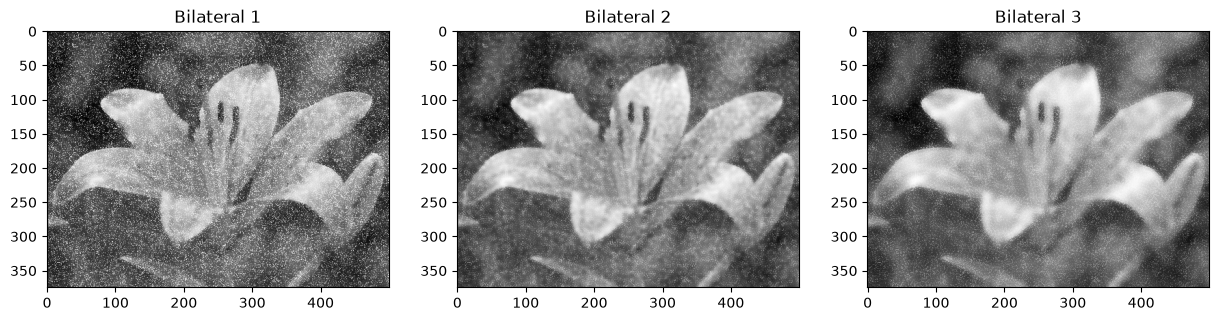

In [7]:
bilat_1 = cv2.bilateralFilter(
    image_noise_gauss,
    9,
    50,
    50
)


bilat_2 = cv2.bilateralFilter(
    image_noise_gauss,
    9,
    100,
    100
)


bilat_3 = cv2.bilateralFilter(
    image_noise_gauss,
    15,
    100,
    100
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(bilat_1,cmap="gray")
plt.title("Bilateral 1")


plt.subplot(1,3,2)
plt.imshow(bilat_2,cmap="gray")
plt.title("Bilateral 2")


plt.subplot(1,3,3)
plt.imshow(bilat_3,cmap="gray")
plt.title("Bilateral 3")

Text(0.5, 1.0, 'NLM h=30')

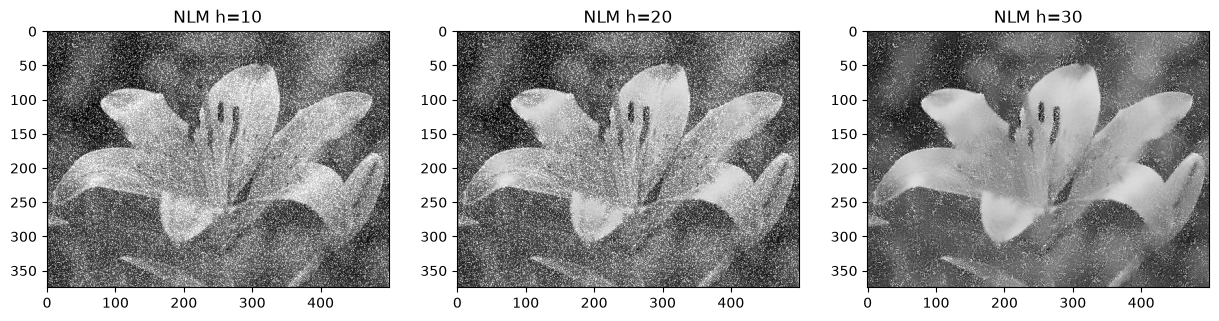

In [8]:
nlm_10 = cv2.fastNlMeansDenoising(
    image_noise_gauss,
    None,
    10
)


nlm_20 = cv2.fastNlMeansDenoising(
    image_noise_gauss,
    None,
    20
)


nlm_30 = cv2.fastNlMeansDenoising(
    image_noise_gauss,
    None,
    30
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(nlm_10,cmap="gray")
plt.title("NLM h=10")


plt.subplot(1,3,2)
plt.imshow(nlm_20,cmap="gray")
plt.title("NLM h=20")


plt.subplot(1,3,3)
plt.imshow(nlm_30,cmap="gray")
plt.title("NLM h=30")

In [9]:
def compare(original, filtered):

    mse = mean_squared_error(
        original,
        filtered
    )


    ssim = structural_similarity(
        original,
        filtered
    )


    return mse, ssim

In [10]:
filters = {

"Median 3":median_3,
"Median 5":median_5,
"Median 7":median_7,

"Gaussian 3":gauss_3,
"Gaussian 5":gauss_5,
"Gaussian 7":gauss_7,

"Bilateral 1":bilat_1,
"Bilateral 2":bilat_2,
"Bilateral 3":bilat_3,

"NLM 10":nlm_10,
"NLM 20":nlm_20,
"NLM 30":nlm_30

}


for name,img in filters.items():

    mse,ssim = compare(
        image_gray,
        img
    )

    print(
        name,
        " MSE:",
        round(mse,2),
        " SSIM:",
        round(ssim,4)
    )

Median 3  MSE: 854.68  SSIM: 0.2636
Median 5  MSE: 408.4  SSIM: 0.4649
Median 7  MSE: 312.33  SSIM: 0.5947
Gaussian 3  MSE: 1673.64  SSIM: 0.301
Gaussian 5  MSE: 1520.15  SSIM: 0.4099
Gaussian 7  MSE: 1449.64  SSIM: 0.5266
Bilateral 1  MSE: 2232.85  SSIM: 0.1627
Bilateral 2  MSE: 1295.93  SSIM: 0.3737
Bilateral 3  MSE: 1284.21  SSIM: 0.3622
NLM 10  MSE: 3784.37  SSIM: 0.0922
NLM 20  MSE: 3687.5  SSIM: 0.117
NLM 30  MSE: 2151.64  SSIM: 0.2585


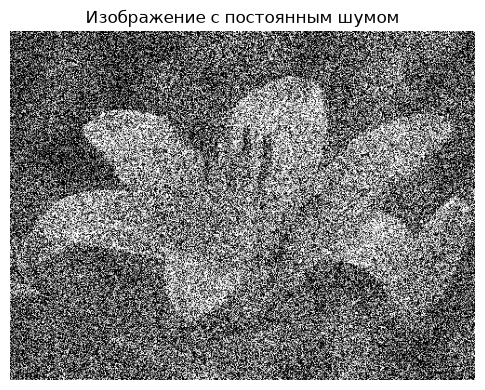

In [11]:
# Постоянный (равномерный) шум
np.random.seed(42)

noise_const = np.random.uniform(
    -200,
    200,
    image_gray.shape
)

image_noise_const = np.clip(
    image_gray.astype(np.float32) + noise_const,
    0,
    255
).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(image_noise_const, cmap="gray")
plt.title("Изображение с постоянным шумом")
plt.axis("off")
plt.show()


## Медианный фильтр для постоянного шума

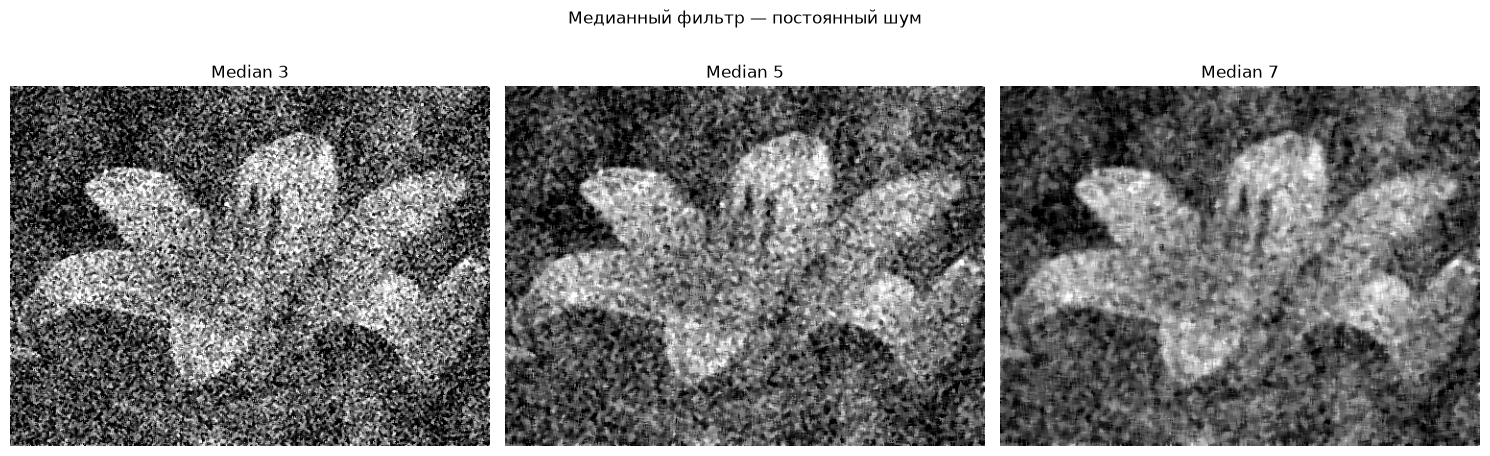

In [12]:
median_const_3 = cv2.medianBlur(image_noise_const, 3)
median_const_5 = cv2.medianBlur(image_noise_const, 5)
median_const_7 = cv2.medianBlur(image_noise_const, 7)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(median_const_3, cmap="gray")
plt.title("Median 3")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(median_const_5, cmap="gray")
plt.title("Median 5")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(median_const_7, cmap="gray")
plt.title("Median 7")
plt.axis("off")

plt.suptitle("Медианный фильтр — постоянный шум")
plt.tight_layout()
plt.show()


## Фильтр Гаусса для постоянного шума

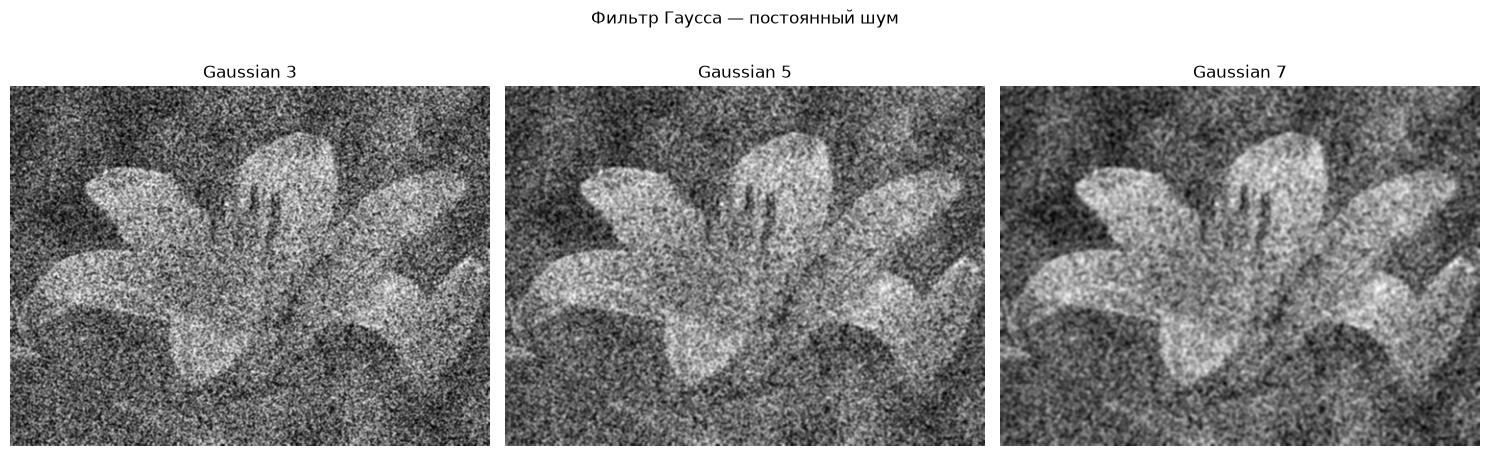

In [13]:
gauss_const_3 = cv2.GaussianBlur(image_noise_const, (3, 3), 0)
gauss_const_5 = cv2.GaussianBlur(image_noise_const, (5, 5), 0)
gauss_const_7 = cv2.GaussianBlur(image_noise_const, (7, 7), 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gauss_const_3, cmap="gray")
plt.title("Gaussian 3")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gauss_const_5, cmap="gray")
plt.title("Gaussian 5")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gauss_const_7, cmap="gray")
plt.title("Gaussian 7")
plt.axis("off")

plt.suptitle("Фильтр Гаусса — постоянный шум")
plt.tight_layout()
plt.show()


## Билатеральный фильтр для постоянного шума

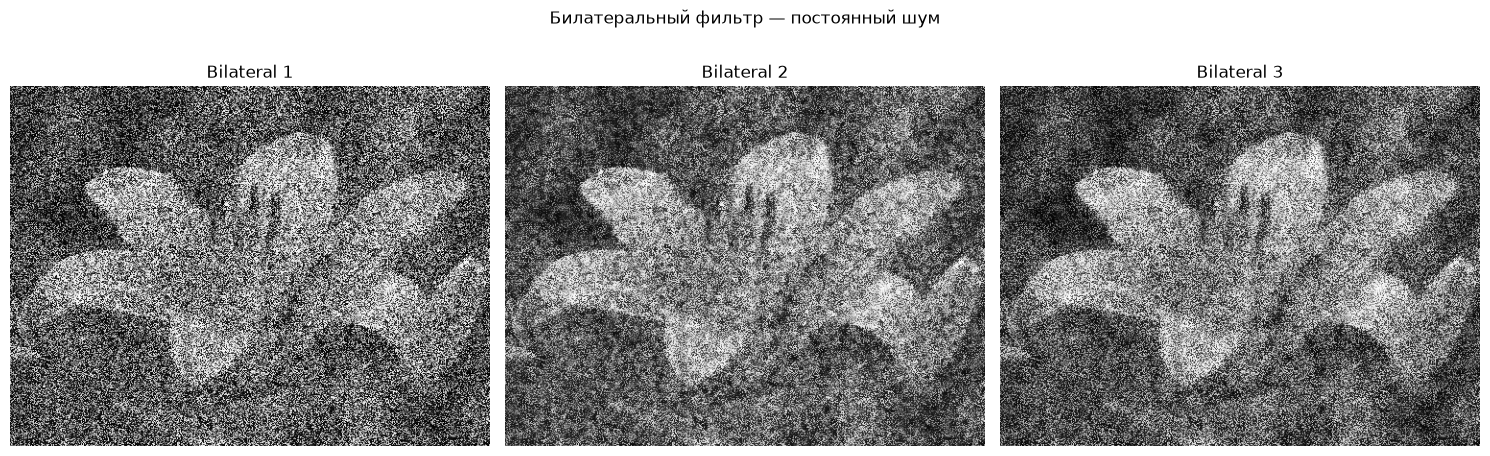

In [14]:
bilat_const_1 = cv2.bilateralFilter(image_noise_const, 9, 50, 50)
bilat_const_2 = cv2.bilateralFilter(image_noise_const, 9, 100, 100)
bilat_const_3 = cv2.bilateralFilter(image_noise_const, 15, 100, 100)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(bilat_const_1, cmap="gray")
plt.title("Bilateral 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bilat_const_2, cmap="gray")
plt.title("Bilateral 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilat_const_3, cmap="gray")
plt.title("Bilateral 3")
plt.axis("off")

plt.suptitle("Билатеральный фильтр — постоянный шум")
plt.tight_layout()
plt.show()


## Фильтр нелокальных средних для постоянного шума

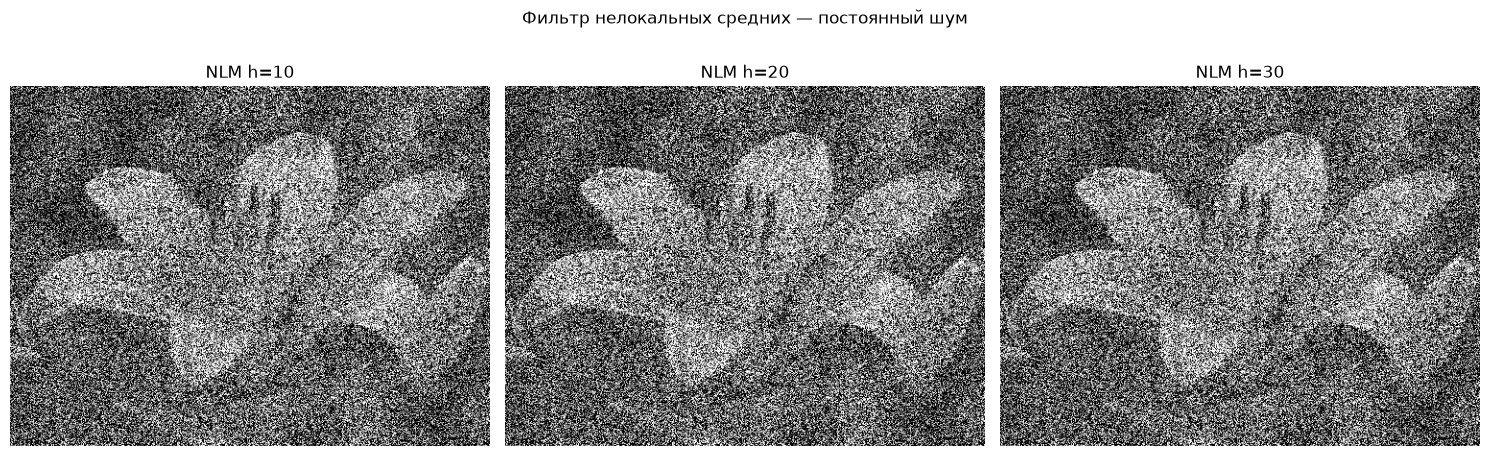

In [15]:
nlm_const_10 = cv2.fastNlMeansDenoising(
    image_noise_const, None, 10
)
nlm_const_20 = cv2.fastNlMeansDenoising(
    image_noise_const, None, 20
)
nlm_const_30 = cv2.fastNlMeansDenoising(
    image_noise_const, None, 30
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(nlm_const_10, cmap="gray")
plt.title("NLM h=10")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(nlm_const_20, cmap="gray")
plt.title("NLM h=20")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(nlm_const_30, cmap="gray")
plt.title("NLM h=30")
plt.axis("off")

plt.suptitle("Фильтр нелокальных средних — постоянный шум")
plt.tight_layout()
plt.show()


## Сравнение результатов для обоих видов шума

In [ ]:

filters_const = {
    "Median 3": median_const_3,
    "Median 5": median_const_5,
    "Median 7": median_const_7,
    "Gaussian 3": gauss_const_3,
    "Gaussian 5": gauss_const_5,
    "Gaussian 7": gauss_const_7,
    "Bilateral 1": bilat_const_1,
    "Bilateral 2": bilat_const_2,
    "Bilateral 3": bilat_const_3,
    "NLM 10": nlm_const_10,
    "NLM 20": nlm_const_20,
    "NLM 30": nlm_const_30
}

print("Результаты для постоянного шума:")
print("-" * 55)

constant_results = {}

for name, img in filters_const.items():
    mse, ssim = compare(image_gray, img)
    constant_results[name] = (mse, ssim)
    print(
        f"{name:<15} "
        f"MSE: {mse:>10.2f}   "
        f"SSIM: {ssim:>7.4f}"
    )


Результаты для постоянного шума:
-------------------------------------------------------
Median 3        MSE:    3118.62   SSIM:  0.0671
Median 5        MSE:    1453.19   SSIM:  0.1256
Median 7        MSE:     840.53   SSIM:  0.2035
Gaussian 3      MSE:    1544.27   SSIM:  0.1173
Gaussian 5      MSE:    1015.99   SSIM:  0.1876
Gaussian 7      MSE:     746.34   SSIM:  0.2922
Bilateral 1     MSE:    6885.77   SSIM:  0.0292
Bilateral 2     MSE:    3165.49   SSIM:  0.0556
Bilateral 3     MSE:    3069.45   SSIM:  0.0524
NLM 10          MSE:    8566.72   SSIM:  0.0248
NLM 20          MSE:    8566.72   SSIM:  0.0248
NLM 30          MSE:    8566.22   SSIM:  0.0248


## Итоговый вывод

In [17]:
# Вывод по результатам фильтрации

gauss_results = {}
for name, img in filters.items():
    gauss_results[name] = compare(image_gray, img)

best_gauss_mse = min(gauss_results.items(), key=lambda x: x[1][0])
best_gauss_ssim = max(gauss_results.items(), key=lambda x: x[1][1])

best_const_mse = min(constant_results.items(), key=lambda x: x[1][0])
best_const_ssim = max(constant_results.items(), key=lambda x: x[1][1])

print("ВЫВОД")
print("=" * 60)

print("Гауссовский шум:")
print(
    f"  Лучший результат по MSE: {best_gauss_mse[0]} "
    f"(MSE = {best_gauss_mse[1][0]:.2f})"
)
print(
    f"  Лучший результат по SSIM: {best_gauss_ssim[0]} "
    f"(SSIM = {best_gauss_ssim[1][1]:.4f})"
)

print()
print("Постоянный шум:")
print(
    f"  Лучший результат по MSE: {best_const_mse[0]} "
    f"(MSE = {best_const_mse[1][0]:.2f})"
)
print(
    f"  Лучший результат по SSIM: {best_const_ssim[0]} "
    f"(SSIM = {best_const_ssim[1][1]:.4f})"
)

print()
print(
    "При сравнении фильтров учитываются две метрики: "
    "MSE (меньше — ближе к исходному изображению) и "
    "SSIM (больше — выше структурное сходство)."
)


ВЫВОД
Гауссовский шум:
  Лучший результат по MSE: Median 7 (MSE = 312.33)
  Лучший результат по SSIM: Median 7 (SSIM = 0.5947)

Постоянный шум:
  Лучший результат по MSE: Gaussian 7 (MSE = 746.34)
  Лучший результат по SSIM: Gaussian 7 (SSIM = 0.2922)

При сравнении фильтров учитываются две метрики: MSE (меньше — ближе к исходному изображению) и SSIM (больше — выше структурное сходство).
